# Custom CSP — `fit` / `transform`

**Goal:** Implement and exercise the sklearn-compatible Common Spatial Patterns transformer from `src/csp.py`.

**Input:** `artifacts/X_s1_runs4_8_12.npy` — shape `(N, 64, T)` — and matching labels.

**What CSP does:** it learns a projection matrix `W` (spatial filters) that maximises the variance of class 1 while minimising the variance of class 2 (and vice versa for the other filters). Each epoch is then reduced to a short **log-variance** feature vector that a classifier can use.

The class inherits `BaseEstimator` + `TransformerMixin` so it can sit in an sklearn `Pipeline`.


### Imports

In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Project root on sys.path whether this notebook is run from `/` or `notebooks/`
ROOT = Path("..") if not Path("src").exists() else Path(".")
sys.path.insert(0, str(ROOT.resolve()))

from src.csp import CSP

ARTIFACTS_DIR = ROOT / "artifacts"


## 1. Toy example — known spatial pattern

Before touching EEG, build two classes with a planted difference:

- class 0: high variance on **channel 0**
- class 1: high variance on **channel 1**

CSP should recover filters that put almost all their weight on those two channels, with eigenvalues close to 1 and 0.


In [2]:
rng = np.random.default_rng(0)

n_epochs, n_channels, n_times = 60, 8, 200

X0 = rng.normal(0, 0.1, size=(n_epochs // 2, n_channels, n_times))
X0[:, 0, :] = rng.normal(0, 1.5, size=(n_epochs // 2, n_times))

X1 = rng.normal(0, 0.1, size=(n_epochs // 2, n_channels, n_times))
X1[:, 1, :] = rng.normal(0, 1.5, size=(n_epochs // 2, n_times))

X_toy = np.concatenate([X0, X1])
y_toy = np.array([0] * (n_epochs // 2) + [1] * (n_epochs // 2))

csp_toy = CSP(n_components=2)
feat_toy = csp_toy.fit_transform(X_toy, y_toy)

print("filters_     :", csp_toy.filters_.shape)
print("eigenvalues_ :", np.round(csp_toy.eigenvalues_, 4))
print("features     :", feat_toy.shape)
print()
print("|filter 0| (should peak on ch0):", np.round(np.abs(csp_toy.filters_[0]), 3))
print("|filter 1| (should peak on ch1):", np.round(np.abs(csp_toy.filters_[1]), 3))


filters_     : (2, 8)
eigenvalues_ : [0.9955 0.0045]
features     : (60, 2)

|filter 0| (should peak on ch0): [1.013e+00 1.000e-03 2.200e-02 3.000e-03 1.200e-02 2.000e-03 4.000e-03
 2.200e-02]
|filter 1| (should peak on ch1): [1.000e-03 1.013e+00 5.000e-03 9.000e-03 7.000e-03 1.300e-02 2.000e-02
 7.000e-03]


## 2. Load real epochs (subject 1, imagery L/R)

Same arrays notebook `03` already checked: 45 trials, 64 channels, 641 samples (0–4 s at 160 Hz).


In [3]:
X = np.load(ARTIFACTS_DIR / "X_s1_runs4_8_12.npy")
y = np.load(ARTIFACTS_DIR / "y_s1_runs4_8_12.npy")

print("X :", X.shape, "  (epochs × channels × times)")
print("y :", y.shape, "labels", np.unique(y, return_counts=True))


X : (45, 64, 641)   (epochs × channels × times)
y : (45,) labels (array([2, 3]), array([23, 22]))


## 3. `fit` — learn spatial filters

`n_components=4` keeps the **2 largest** and **2 smallest** eigenvalues: the most discriminative pair for each class.


In [4]:
csp = CSP(n_components=4)
csp.fit(X, y)

print("filters_     :", csp.filters_.shape, "  (components × channels)")
print("eigenvalues_ :", np.round(csp.eigenvalues_, 4))
print("classes_     :", csp.classes_, "  (C1 then C2)")
print()
print("Eigenvalues near 1  → high variance for class", csp.classes_[0])
print("Eigenvalues near 0  → high variance for class", csp.classes_[1])


filters_     : (4, 64)   (components × channels)
eigenvalues_ : [0.6425 0.6303 0.3871 0.3474]
classes_     : [2 3]   (C1 then C2)

Eigenvalues near 1  → high variance for class 2
Eigenvalues near 0  → high variance for class 3


The first two filters (large λ) and last two (small λ) are the ones we keep. Intermediate eigenvalues near 0.5 are the least discriminative and are discarded.


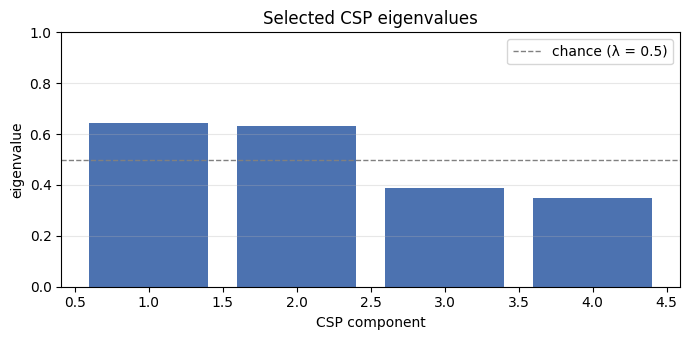

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(np.arange(1, csp.n_components + 1), csp.eigenvalues_, color="#4C72B0")
ax.axhline(0.5, color="0.5", ls="--", lw=1, label="chance (λ = 0.5)")
ax.set_xlabel("CSP component")
ax.set_ylabel("eigenvalue")
ax.set_title("Selected CSP eigenvalues")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()


## 4. `transform` — log-variance features

Each epoch `(64, T)` is projected through `W` then summarised as:

$$f_i = \log\left(\frac{\mathrm{var}(Z_i)}{\sum_j \mathrm{var}(Z_j)}\right)$$

Output shape: `(N, n_components)` — ready for LDA / SVM.


In [6]:
features = csp.transform(X)

print("features :", features.shape, "  (epochs × components)")
print("dtype    :", features.dtype)
print("finite?  :", np.isfinite(features).all())
print()
print("mean log-var per class:")
for cls in csp.classes_:
    print(f"  class {cls}: {np.round(features[y == cls].mean(axis=0), 3)}")


features : (45, 4)   (epochs × components)
dtype    : float64
finite?  : True

mean log-var per class:
  class 2: [-1.194 -1.187 -1.649 -1.806]
  class 3: [-1.702 -1.664 -1.169 -1.249]


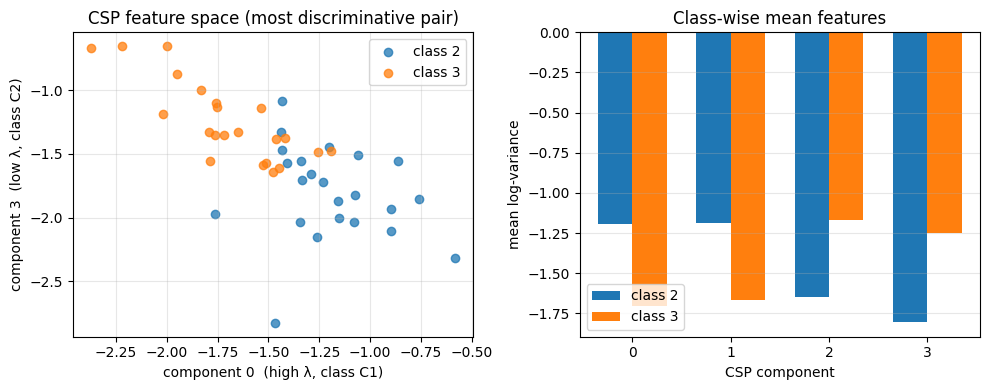

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for cls in csp.classes_:
    mask = y == cls
    axes[0].scatter(
        features[mask, 0],
        features[mask, -1],
        alpha=0.75,
        label=f"class {cls}",
    )
axes[0].set_xlabel("component 0  (high λ, class C1)")
axes[0].set_ylabel("component 3  (low λ, class C2)")
axes[0].set_title("CSP feature space (most discriminative pair)")
axes[0].legend()
axes[0].grid(alpha=0.3)

means = np.stack([features[y == cls].mean(axis=0) for cls in csp.classes_])
x = np.arange(csp.n_components)
w = 0.35
axes[1].bar(x - w / 2, means[0], w, label=f"class {csp.classes_[0]}")
axes[1].bar(x + w / 2, means[1], w, label=f"class {csp.classes_[1]}")
axes[1].set_xticks(x)
axes[1].set_xlabel("CSP component")
axes[1].set_ylabel("mean log-variance")
axes[1].set_title("Class-wise mean features")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()


## 5. Drop into an sklearn Pipeline

This is the interface Phase 4 will use: `CSP` then a classifier. `cross_val_score` evaluates the **whole** pipeline (filters are re-fit on each training fold — no leakage).


In [8]:
pipe = Pipeline([
    ("csp", CSP(n_components=4)),
    ("clf", LinearDiscriminantAnalysis()),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(pipe, X, y, cv=cv)

print("fold scores :", np.round(scores, 3))
print("mean        :", round(float(scores.mean()), 3))
print("std         :", round(float(scores.std()), 3))


fold scores : [0.667 0.556 0.778 0.667 0.889]
mean        : 0.711
std         : 0.113


**What to remember**

| method | input | output |
|---|---|---|
| `fit(X, y)` | `(N, 64, T)` + labels | stores `filters_` `(4, 64)` |
| `transform(X)` | `(N, 64, T)` | `(N, 4)` log-variance features |

Next: `05_compare_mne_csp.ipynb` (Phase 3.3) — compare this transformer against `mne.decoding.CSP`.
